# Lab 05: Data Visualization

## Overview
In this lab, we'll build upon our previous data exploration and enhance our understanding using data visualization.

Our goal is to gain deeper insights into our customer data, which is necessary for our ultimate objective: customer segmentation.



### Summary:

1. Load data and redo preprocessing from last lab  

3. Categorical features visualizations 
    - Univariate distribution 
    - Bivariate distribution 

4. Comparing a categorical variable vs continuous features
    - Numerical vs categorical 
    - Bivariate numerical vs categorical 
    - Numerical vs 3 categoricals 
      
5. A tool to assist you through your exploratory data analysis: pandas-profiling

6. Optional Exercice: project data visualization

# Setup

In [ ]:
# Remember: library imports are ALWAYS at the top of the script, no exceptions!
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

from itertools import product

# for better resolution plots
%config InlineBackend.figure_format = 'retina' # optionally, you can change 'svg' to 'retina'

# Setting seaborn style
sns.set_theme()

# Context
The data we will be using through the pratical classes comes from a small relational database whose schema can be seen below: \
![alt text](../figures/schema.png "Relation database schema")

# Reading the Data

In [4]:
# path to database
my_path = os.path.join("..", "data", "datamining.db")

# connect to the database
conn = sqlite3.connect(my_path)

# the query
query = """
select
    age, 
    income, 
    frq, 
    rcn, 
    mnt, 
    clothes, 
    kitchen, 
    small_appliances, 
    toys, 
    house_keeping,
    dependents, 
    per_net_purchase,
    g.gender, 
    e.education, 
    m.status, 
    r.description
from customers as c
    join genders as g on g.id = c.gender_id
    join education_levels as e on e.id = c.education_id
    join marital_status as m on m.id = c.marital_status_id
    join recommendations as r on r.id = c.recommendation_id
order by c.id;
"""

df = pd.read_sql_query(query, conn)

# Metadata
- *id* - The unique identifier of the customer
- *age* - The year of birht of the customer
- *income* - The income of the customer
- *frq* - Frequency: number of purchases made by the customer
- *rcn* - Recency: number of days since last customer purchase
- *mnt* - Monetary: amount of € spent by the customer in purchases
- *clothes* - Number of clothes items purchased by the customer
- *kitchen* - Number of kitchen items purchased by the customer
- *small_appliances* - Number of small_appliances items purchased by the customer
- *toys* - Number of toys items purchased by the customer
- *house_keeping* - Number of house_keeping items purchased by the customer
- *dependents* - Binary. Whether or not the customer has dependents
- *per_net_purchase* - Percentage of purchases made online
- *education* - Education level of the customer
- *status* - Marital status of the customer
- *gender* - Gender of the customer
- *description* - Last customer's recommendation description

# Initial Analysis

Pandas user guide: https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html

Pandas 10 min tutorial: https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html

## Potential Problems:
- Duplicates?
- Data types?
- Missing values?
- Strange values?
- Descriptive statistics?

### Insights from previous notebook:

- Duplicates?
    - We didn't find any
- Data types?
    - `income` was being recognized as `object` (empty strings)
    - `dependents` was being recognized as `object` (empty strings)

<div align="center">

| Metric Features   | Non-Metric Features |
|-------------------|---------------------|
| age               | dependents          |
| income            | gender              |
| frq               | education           |
| rcn               | status              |
| mnt               | description         |
| clothes           |                     |
| kitchen           |                     |
| small_appliances  |                     |
| toys              |                     |
| house_keeping     |                     |

</div>


- Missing values?
    - replaced empty strings '""' with `np.nan` to reflect that these were missing values
- Strange values?
    - `education` has `OldSchool` category
- Descriptive statistics?
    - Metric: mean, median, min, ...
    - Non-metric: mode (top)


### Replicating modifications from previous notebook

In [5]:
# replace "" by nans
df.replace("", np.nan, inplace=True)

# count of missing values
df.isna().sum()

C:\Users\X1605\AppData\Local\Temp\ipykernel_25604\3385904135.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("", np.nan, inplace=True)


age                   0
income               46
frq                   0
rcn                   0
mnt                   0
clothes               0
kitchen               0
small_appliances      0
toys                  0
house_keeping         0
dependents          282
per_net_purchase      0
gender                0
education            47
status              177
description           0
dtype: int64

In [6]:
# fix wrong dtypes
df.dependents = df.dependents.astype("boolean")  # converting to "boolean" over "bool" allows preservation of NaNs

In [7]:
# check dataset data types again
df.dtypes

age                   int64
income              float64
frq                   int64
rcn                   int64
mnt                   int64
clothes               int64
kitchen               int64
small_appliances      int64
toys                  int64
house_keeping         int64
dependents          boolean
per_net_purchase      int64
gender               object
education            object
status               object
description          object
dtype: object

In [8]:
# check descriptive statistics again
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,8998.0,1966.06,17.30,1936.0,1951.0,1966.0,1981.0,1996.0
income,8952.0,69963.55,27591.56,10000.0,47741.0,70030.5,92218.0,140628.0
frq,8998.0,19.85,10.90,3.0,10.0,17.0,28.0,59.0
rcn,8998.0,62.47,69.76,0.0,26.0,53.0,79.0,549.0
mnt,8998.0,622.16,646.77,6.0,63.0,383.0,1076.0,3052.0
clothes,8998.0,50.45,23.42,1.0,33.0,51.0,69.0,99.0
kitchen,8998.0,7.04,7.85,0.0,2.0,4.0,10.0,75.0
small_appliances,8998.0,28.52,12.59,1.0,19.0,28.0,37.0,74.0
toys,8998.0,7.04,7.92,0.0,2.0,4.0,10.0,62.0
house_keeping,8998.0,6.93,7.88,0.0,2.0,4.0,9.0,77.0


In [9]:
# check descriptive statistics again
df.describe(include=["O", bool]).T

,count,unique,top,freq
dependents,8716,2,True,6164
gender,8998,2,M,5784
education,8951,6,Graduation,4429
status,8821,6,Married,3273
description,8998,5,OK nice!,3434


# Visual Exploration tools

Matplotlib tutorials: https://matplotlib.org/stable/tutorials/index.html

Matplotlib gallery: https://matplotlib.org/stable/gallery/index.html

Seaborn tutorials: https://seaborn.pydata.org/tutorial.html


Seaborn gallery: https://seaborn.pydata.org/examples/index.html

### Matplotlib vs Seaborn:

**Matplotlib** - lower level. allows to fully customize the plot appearance

**Seaborn** - higher level. Complex off-the-shelf plots with one line. Matplotlib on steroids


In [10]:
#Define metric and non-metric features. Why?
non_metric_features = ["education", "status", "gender", "dependents", "description"]
metric_features = df.columns.drop(non_metric_features).to_list()

######## OR ########
# metric_features = ['age', 'income', 'frq', 'rcn', 'mnt', 
#                    'clothes', 'kitchen', 'small_appliances', 'toys', 'house_keeping', 
#                    'per_net_purchase']


# Categorical/Low Cardinality Variables' Absolute Frequencies

## Univariate Categorical Distribution

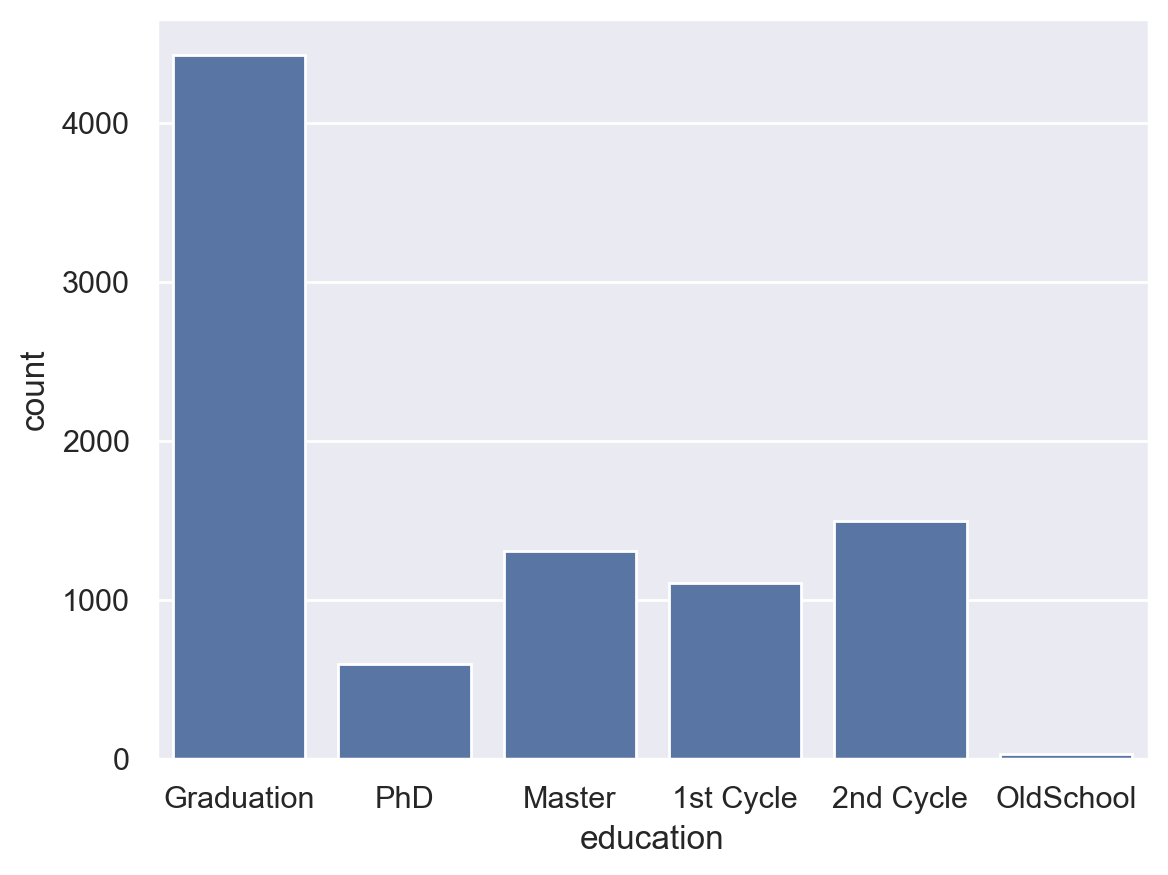

In [11]:
# Single Non-Metric variable bar plot
sns.set_style() # this resets our formatting defaults
sns.countplot(x=df["education"])

plt.show()

# How can we improve this figure?

Try choosing a custom `color` such as "blue" or "red" or "orange"

Alternatively, you can get values for custom RGB codes for any given color here: https://www.w3schools.com/colors/colors_picker.asp

Any other color picker will do just as well


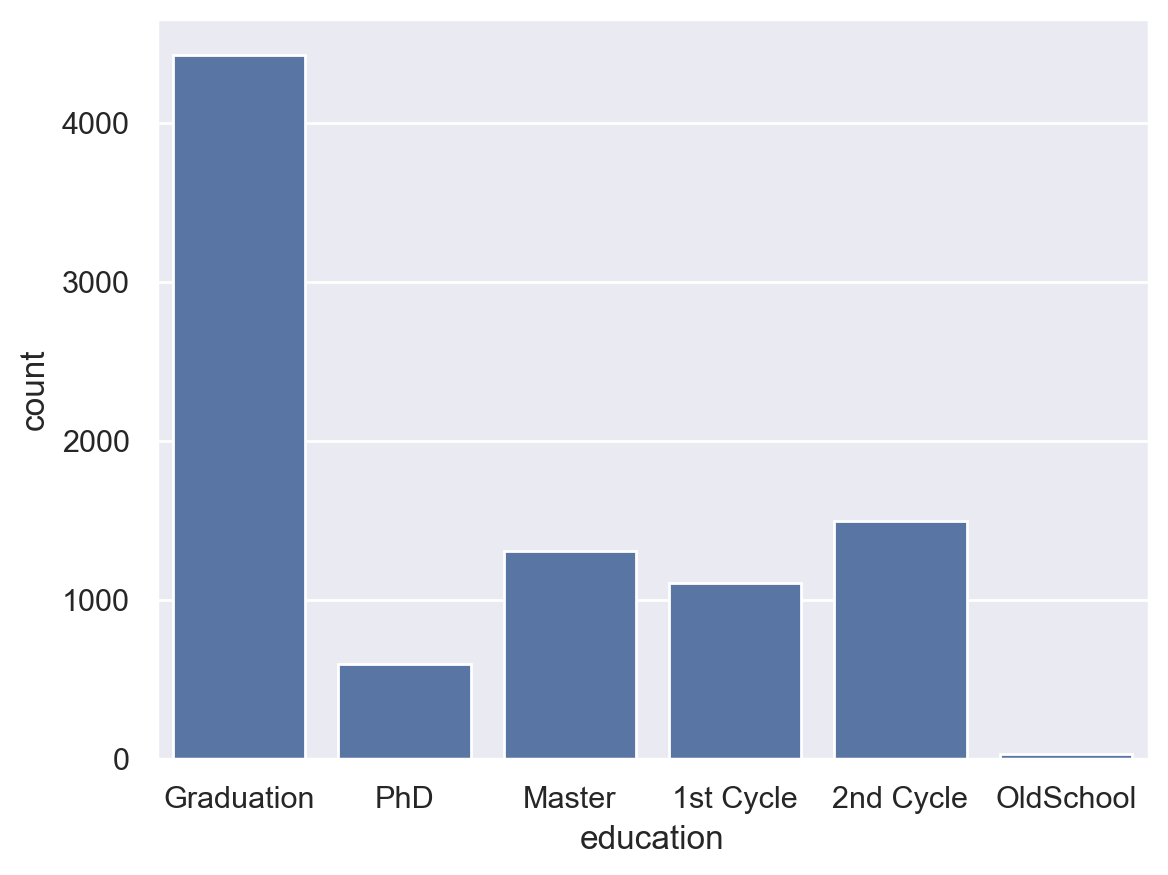

In [12]:
# Format the color of a simple bar chart

sns.countplot(x=df["education"])
plt.show()

# How can we improve this figure?

### Exercise 7: Show the above figure with the bars sorted from largest to smallest. <br>Do this in an automatic way.

`countplot` documentation:

https://seaborn.pydata.org/generated/seaborn.countplot.html

*Hints*

- `countplot` has an `order` parameter.
- `df.value_counts()`: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html

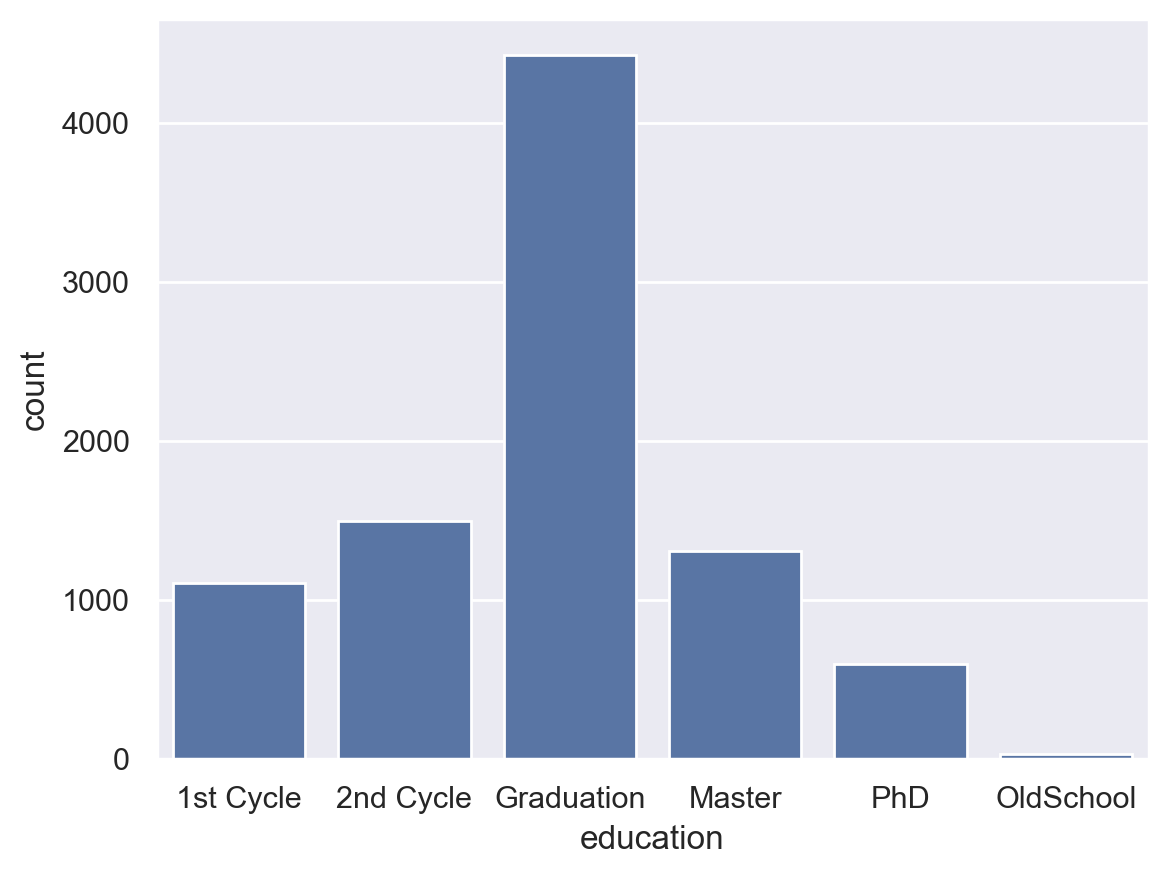

In [13]:
## Sort the bars from largest to smallest

sns.countplot(x=df["education"],
              order=["1st Cycle", "2nd Cycle", "Graduation", "Master", "PhD", "OldSchool"] ## Do this in an automatic way.
             )
plt.show()

# How can we improve this figure?

What information can we extract from the plot above?

### Exercise 8: Using the same logic from the multiple box plot figure above, build a multiple bar plot figure for each non-metric variable

In [14]:
## Remember:

non_metric_features

['education', 'status', 'gender', 'dependents', 'description']

In [15]:
# Remember: dependents has nan values, which cause errors when trying to plot. 
df.dependents.unique()



<BooleanArray>
[False, True, <NA>]
Length: 3, dtype: boolean

In [16]:
# For now, we convert dependents to string and replace the missing values with the string 'NAN'. 
# Remember to use df_deps instead of df for visualizing in this section

df_deps = df.copy()
df_deps['dependents'] = df_deps['dependents'].astype('str')


In [17]:
print('Percentage of rows with dependents missing:')

np.round(df['dependents'].isna().sum()/df.shape[0]*100, 2)


Percentage of rows with dependents missing:


np.float64(3.13)

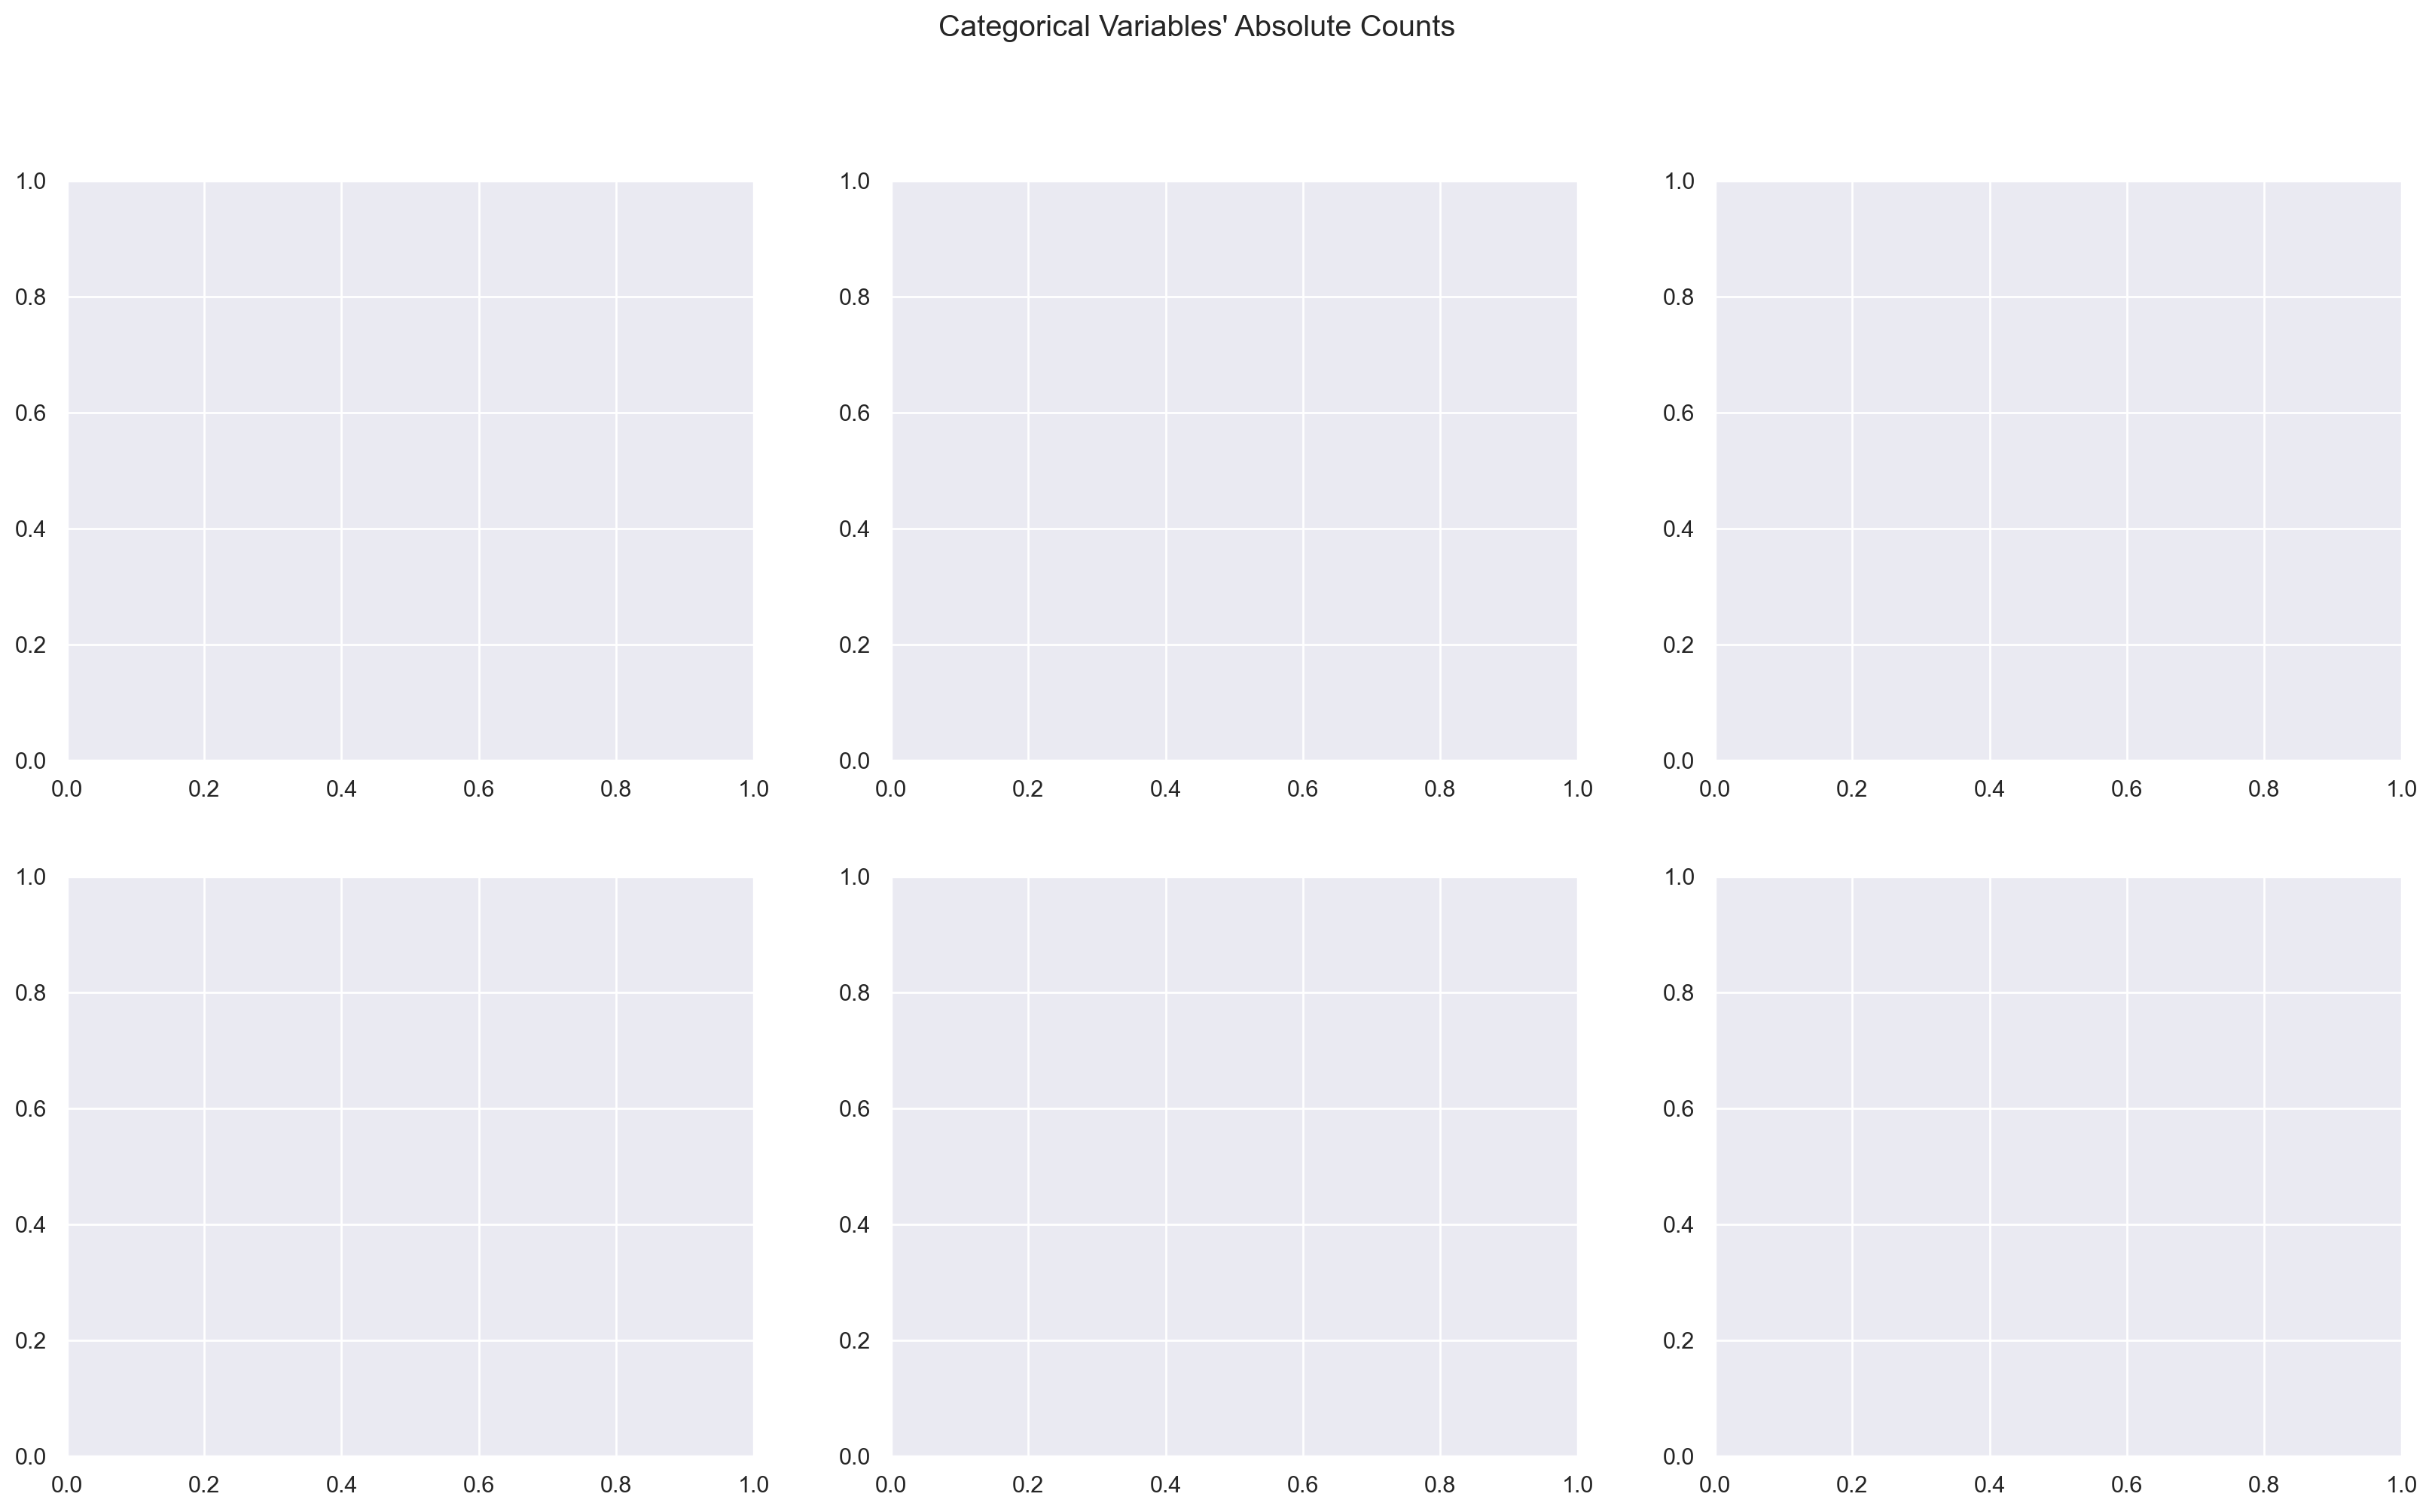

In [18]:
# All Non-Metric Variables' Absolute Frequencies
sns.set_style() # this resets our formatting defaults

# Prepare figure. Create individual axes where each bar plot will be placed
fig, axes = plt.subplots(2, ceil(len(non_metric_features) / 2), figsize=(20, 11))

# Plot data
# Iterate across axes objects and associate each bar plot (hint: use the ax argument):
for ax, feat in zip(axes.flatten(), non_metric_features): # Notice the zip() function and flatten() method
    # What should be here?
    pass # placeholder to avoid errors when running; remove this

title = "Categorical Variables' Absolute Counts"
plt.suptitle(title)

# plt.savefig(os.path.join('..', 'figures', 'eda', 'categorical_variables_counts.png'), dpi=200)
plt.show()

### Categorical univariate visualization overview: 
- Countplot (Bar plots) 

### Insights:
- low frequency values
- high cardinality

## Bivariate Categorical Distribution - Comparing two categorical variables

Now, let's investigate the relationships between categorical variables.

Comparing these variables can reveal insights into how different customer groups are distributed across categories like sentiment, gender, and education level.

We will use stacked bar plots to visualize these relationships, showing both the absolute counts and the proportions within each category.

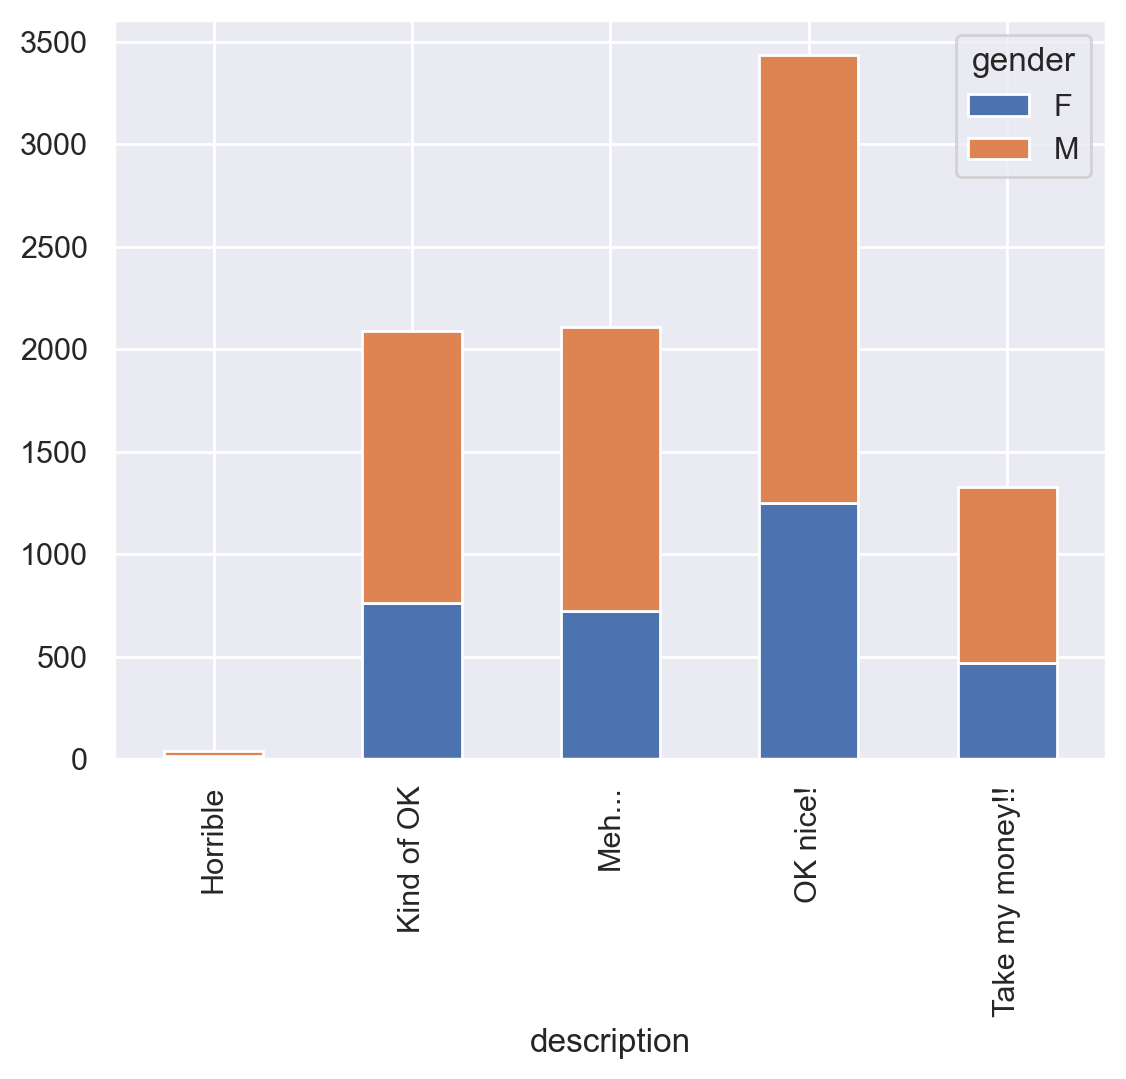

In [19]:
cat1 = 'description'
cat2 = 'gender'

catpc_df = df.groupby([cat1, cat2])[cat2].size().unstack()

catpc_df.plot.bar(stacked=True)


plt.show()

# Let's break this down

In [20]:
# Let's break this down

cat1 = 'description'
cat2 = 'gender'


df.groupby([cat1, cat2])[cat2].size()

description      gender
Horrible         F           14
                 M           27
Kind of OK       F          761
                 M         1329
Meh...           F          723
                 M         1384
OK nice!         F         1248
                 M         2186
Take my money!!  F          468
                 M          858
Name: gender, dtype: int64

In [21]:
df.groupby([cat1, cat2])[cat2].size().unstack()

gender,F,M
description,,
Horrible,14,27
Kind of OK,761,1329
Meh...,723,1384
OK nice!,1248,2186
Take my money!!,468,858


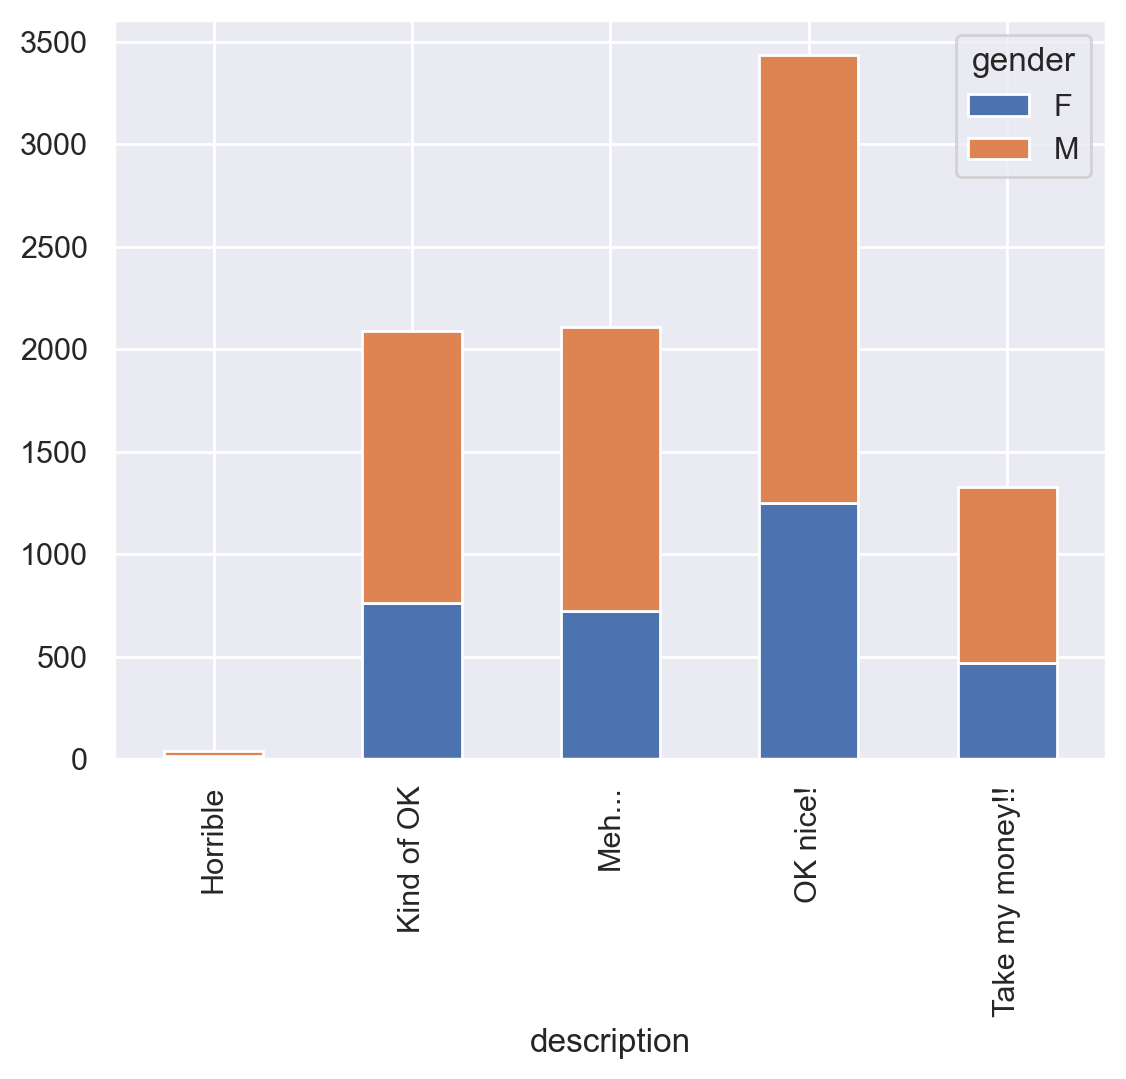

In [22]:
df.groupby([cat1, cat2])[cat2].size().unstack().plot.bar(stacked=True)

plt.show()

# How can we improve this figure?

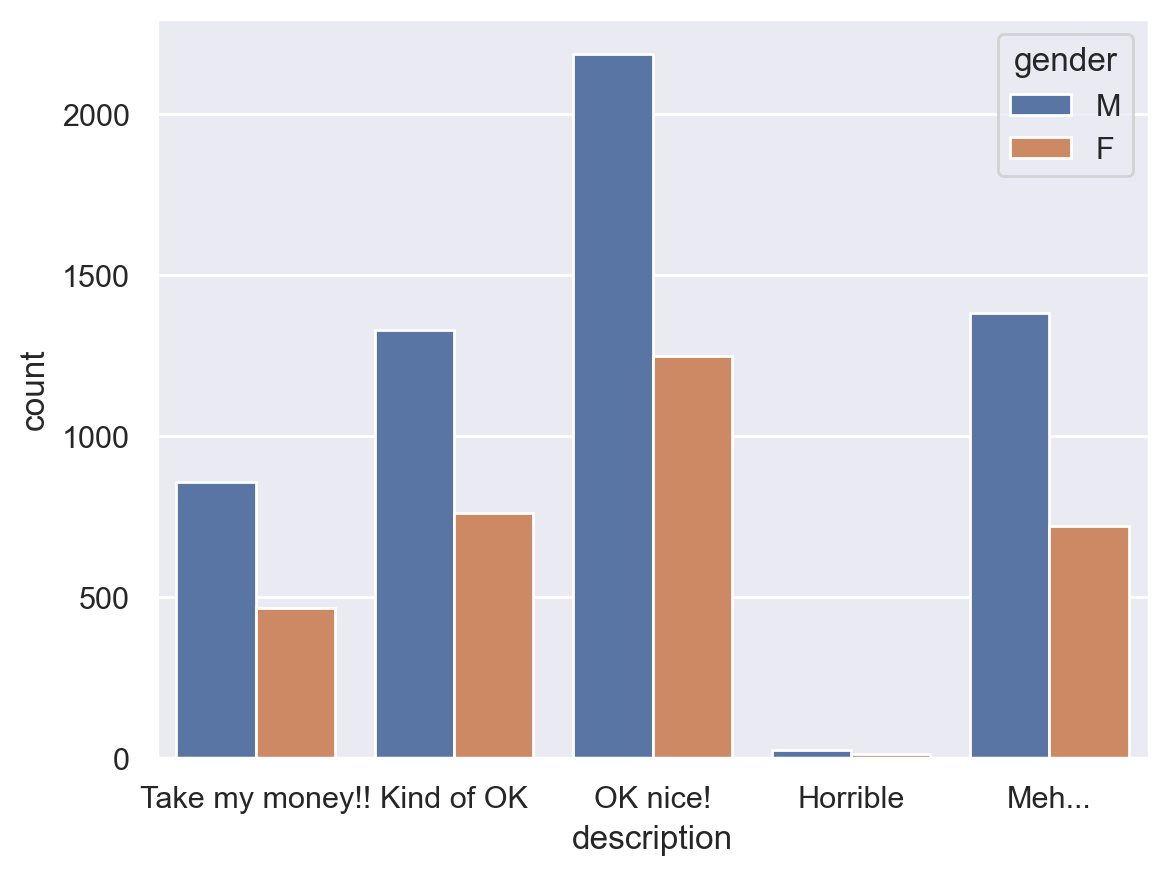

In [23]:
# Using seaborn

# sns.countplot does not have stacked option
sns.countplot(df, x="description", hue="gender")

plt.show()

#### Exercise 9: Plot the **relative** counts of the bar plots

*Hint* How do we calculate the relative percentage of `dependents` for each category of `description`?


In this case, we want a full bar for each description category. Using the `Horrible` category for example:
```
description      gender
Horrible         F           14
                 M           27
```

We want:
- the `gender=F` part to be `14/(14+27) %` of the bar, and 
- the `gender=M` part to be `27/(14+27) %` of the bar.



In [24]:
# Remember:
df.groupby([cat1, cat2])[cat2].size().unstack()

gender,F,M
description,,
Horrible,14,27
Kind of OK,761,1329
Meh...,723,1384
OK nice!,1248,2186
Take my money!!,468,858


In [25]:
# Here we want the counts of each description category:
# What should be here?

df.groupby([cat1, cat2])[cat2].size().unstack().sum(axis=1)


description
Horrible             41
Kind of OK         2090
Meh...             2107
OK nice!           3434
Take my money!!    1326
dtype: int64

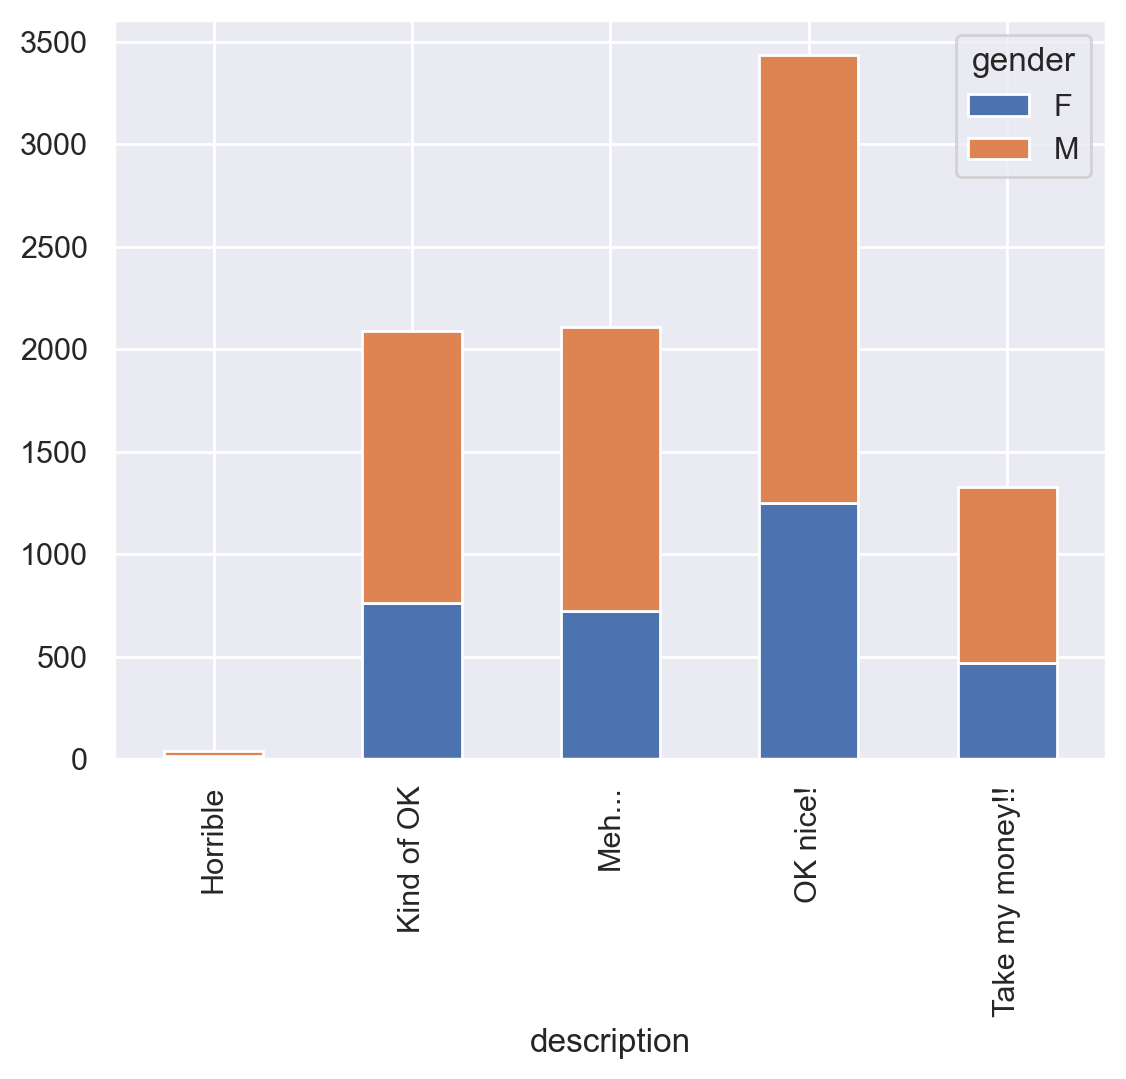

In [26]:
# Putting it all together:

cat1 = 'description'
cat2 = 'gender'

# Many ways to do this
catpc_df = df.groupby([cat1, cat2])[cat2].size() / 1 

catpc_df.unstack().plot.bar(stacked=True)


plt.show()

## Description vs Education

Examine the stacked bar plots for description vs **gender** and **description** vs **education**.

What differences do you observe between the absolute and proportional views? Where might a decision-maker misinterpret the data if they only looked at absolute counts?

How would your interpretation of customer satisfaction differ if you only looked at the raw counts?

What patterns emerge only when you consider proportional distributions

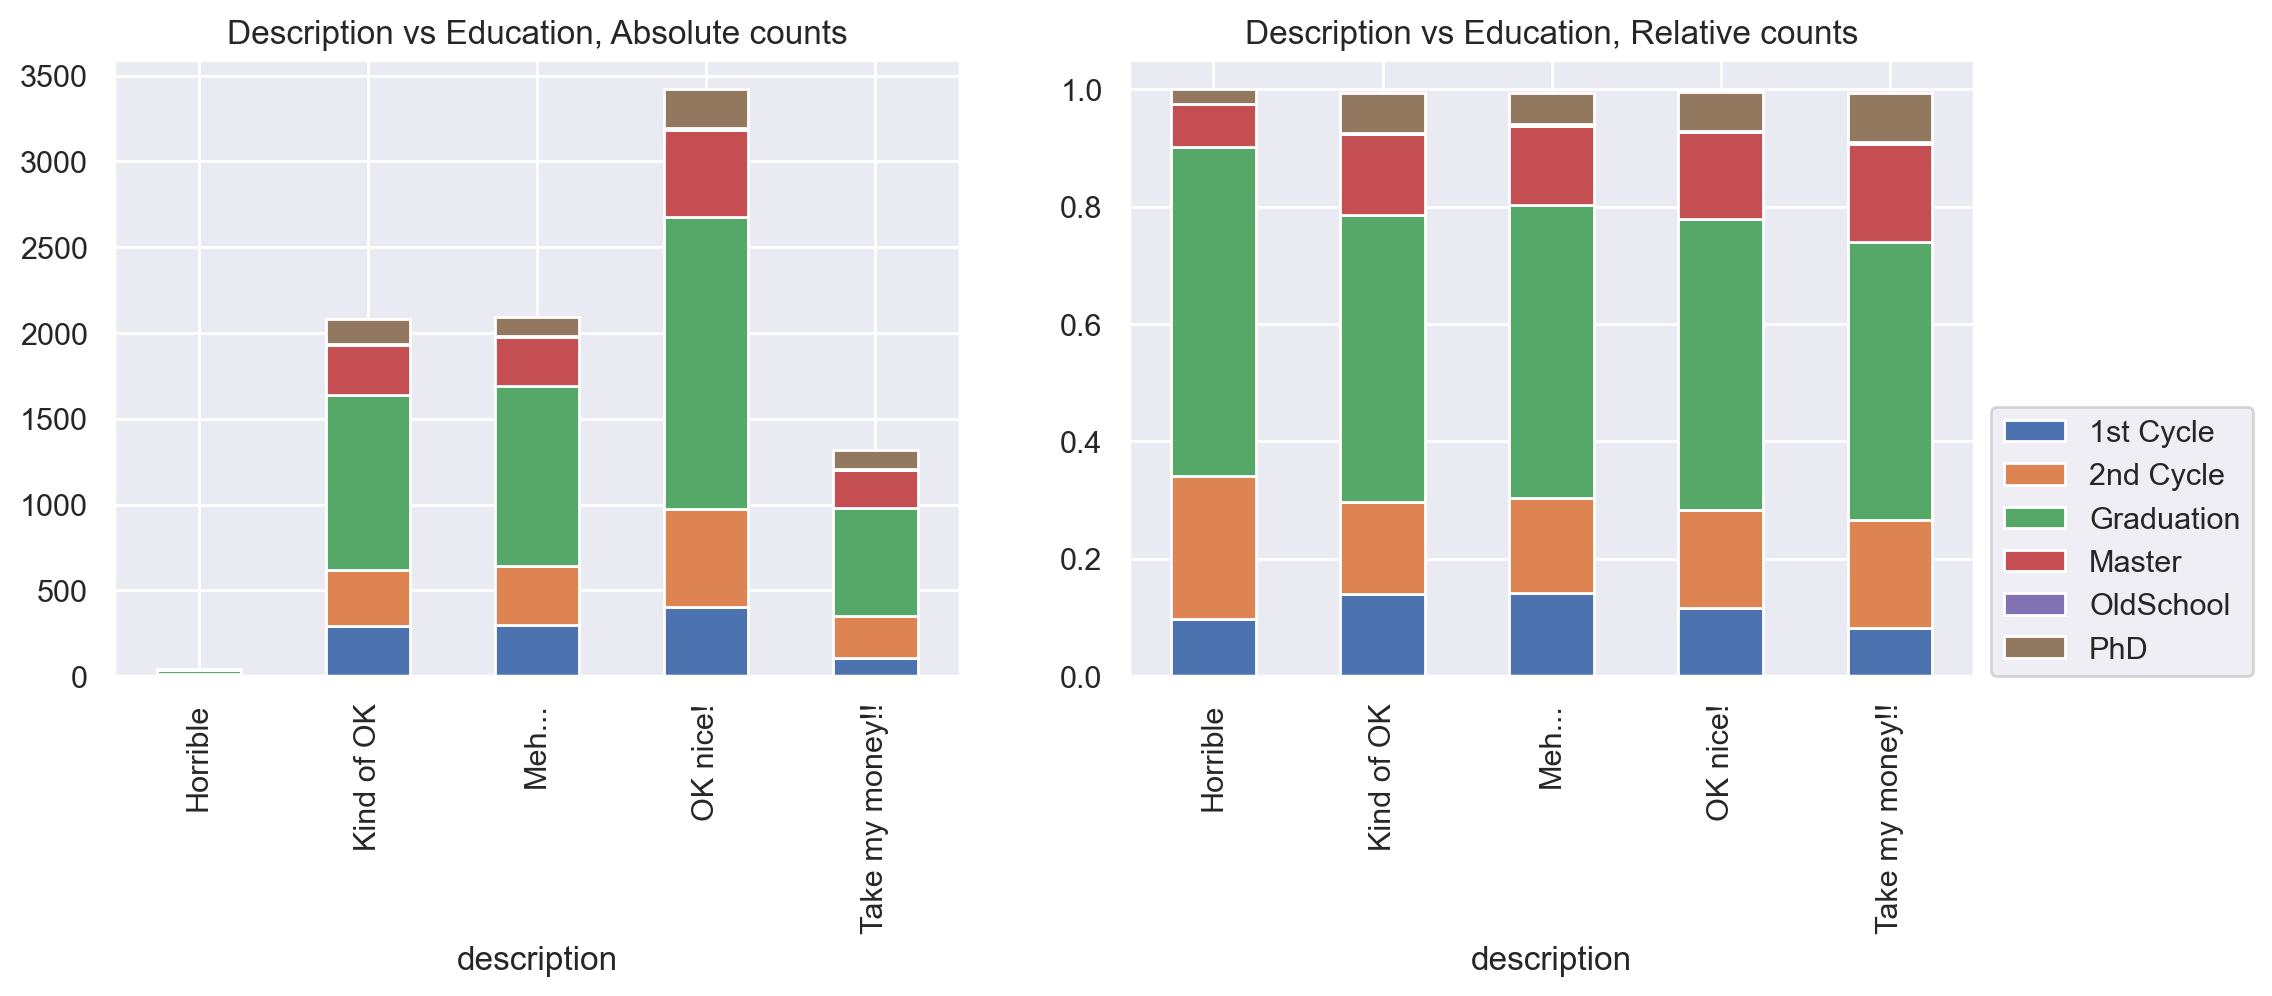

In [27]:
# What about description vs education?

cat1 = 'description'
cat2 = 'education'

fig, axes = plt.subplots(1,2, figsize=(12,4))

catpc_df = df.groupby([cat1, cat2])[cat2].size().unstack()
catpc_df.plot.bar(stacked=True, ax=axes[0])
axes[0].set_title('Description vs Education, Absolute counts')
axes[0].legend([], frameon=False) # hide legend on right subplot

catpc_df2 = df.groupby([cat1, cat2])[cat2].size() / df.groupby([cat1])[cat2].size() 
catpc_df2.unstack().plot.bar(stacked=True, ax=axes[1])
axes[1].set_title('Description vs Education, Relative counts')
axes[1].legend(loc=(1.02,0)) # reposition legend on right subplot

plt.show()


plt.show()

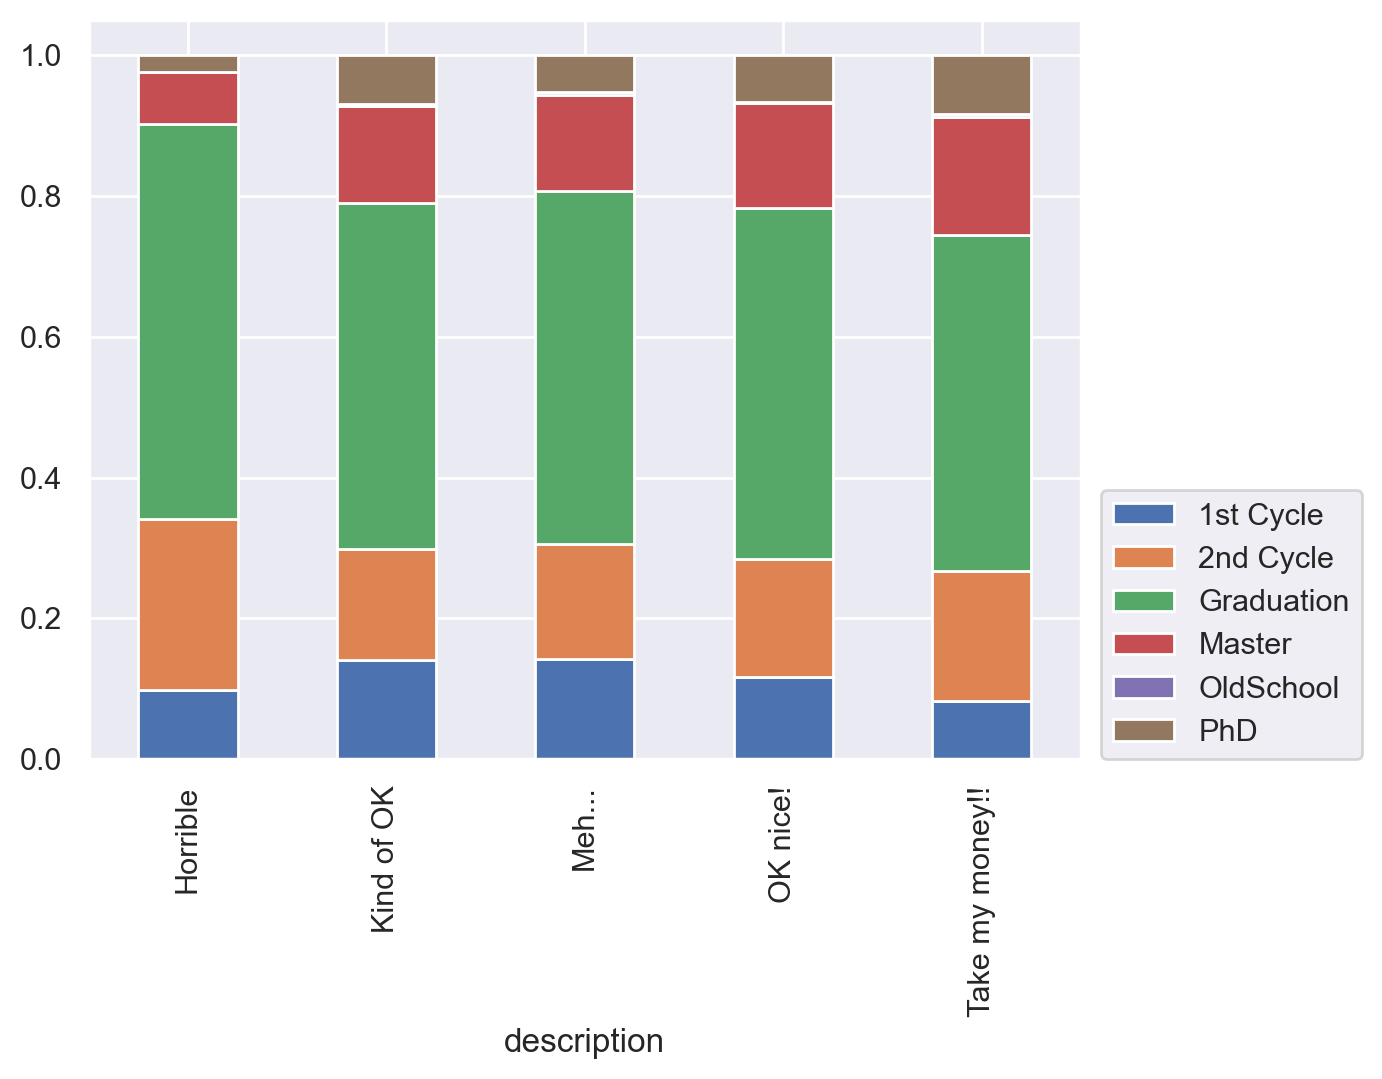

In [28]:
# Another way to do this creating a crosstab

pd.crosstab(df['description'], df['education'], normalize='index').plot.bar(stacked=True)
plt.legend(loc=(1.02,0)) # reposition legend on right subplot
plt.show()

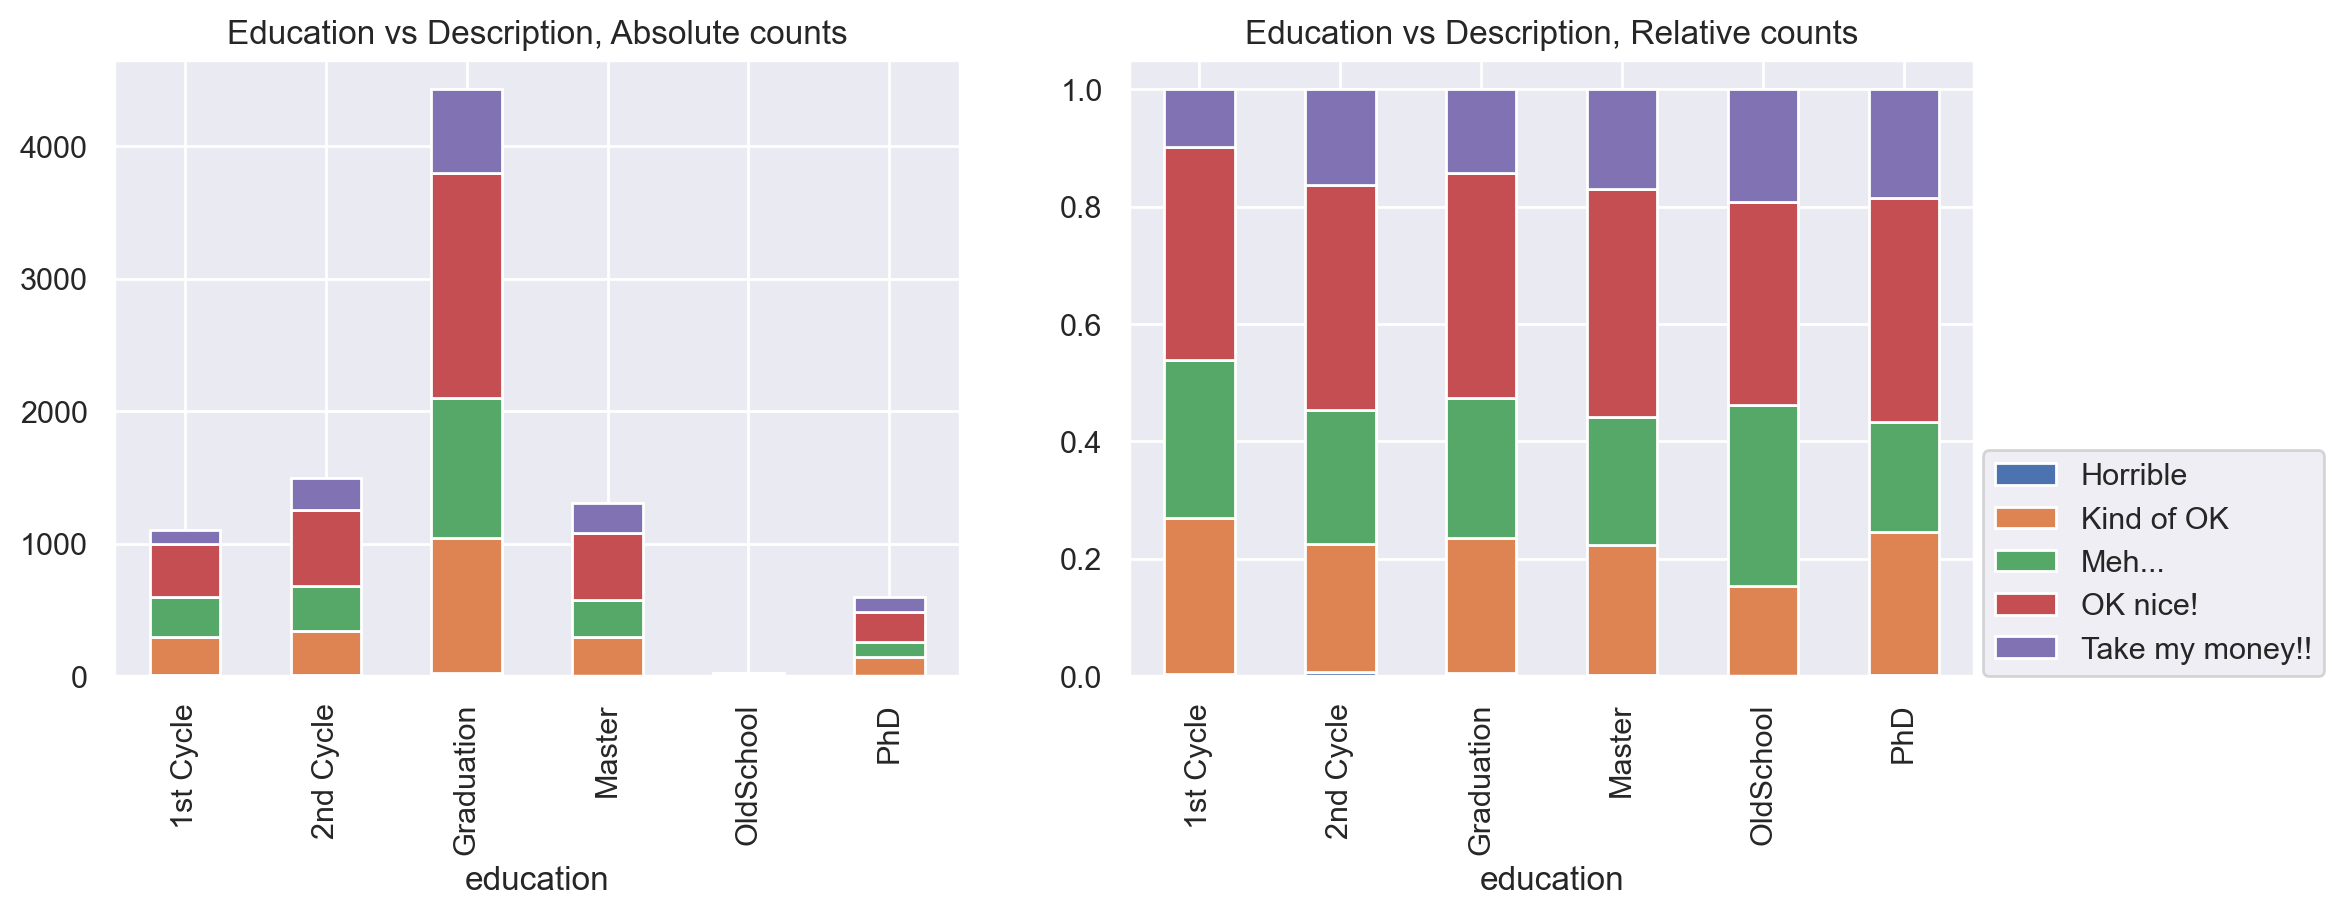

In [29]:
# What about description vs education? 
# This time flip the two

cat1 = 'education'
cat2 = 'description'

fig, axes = plt.subplots(1,2, figsize=(12,4))

catpc_df = df.groupby([cat1, cat2])[cat2].size().unstack()
catpc_df.plot.bar(stacked=True, ax=axes[0])
axes[0].legend([], frameon=False)
axes[0].set_title('Education vs Description, Absolute counts')

catpc_df2 = df.groupby([cat1, cat2])[cat2].size() / df.groupby([cat1])[cat2].size() 

catpc_df2.unstack().plot.bar(stacked=True, ax=axes[1])
axes[1].set_title('Education vs Description, Relative counts')
axes[1].legend(loc=(1.01,0))

plt.show()


plt.show()

### Categorical Bivariate overview: 
- Bar plots of contingency tables 

# Comparing a categorical variable vs continuous (or discrete) variables

### Histograms

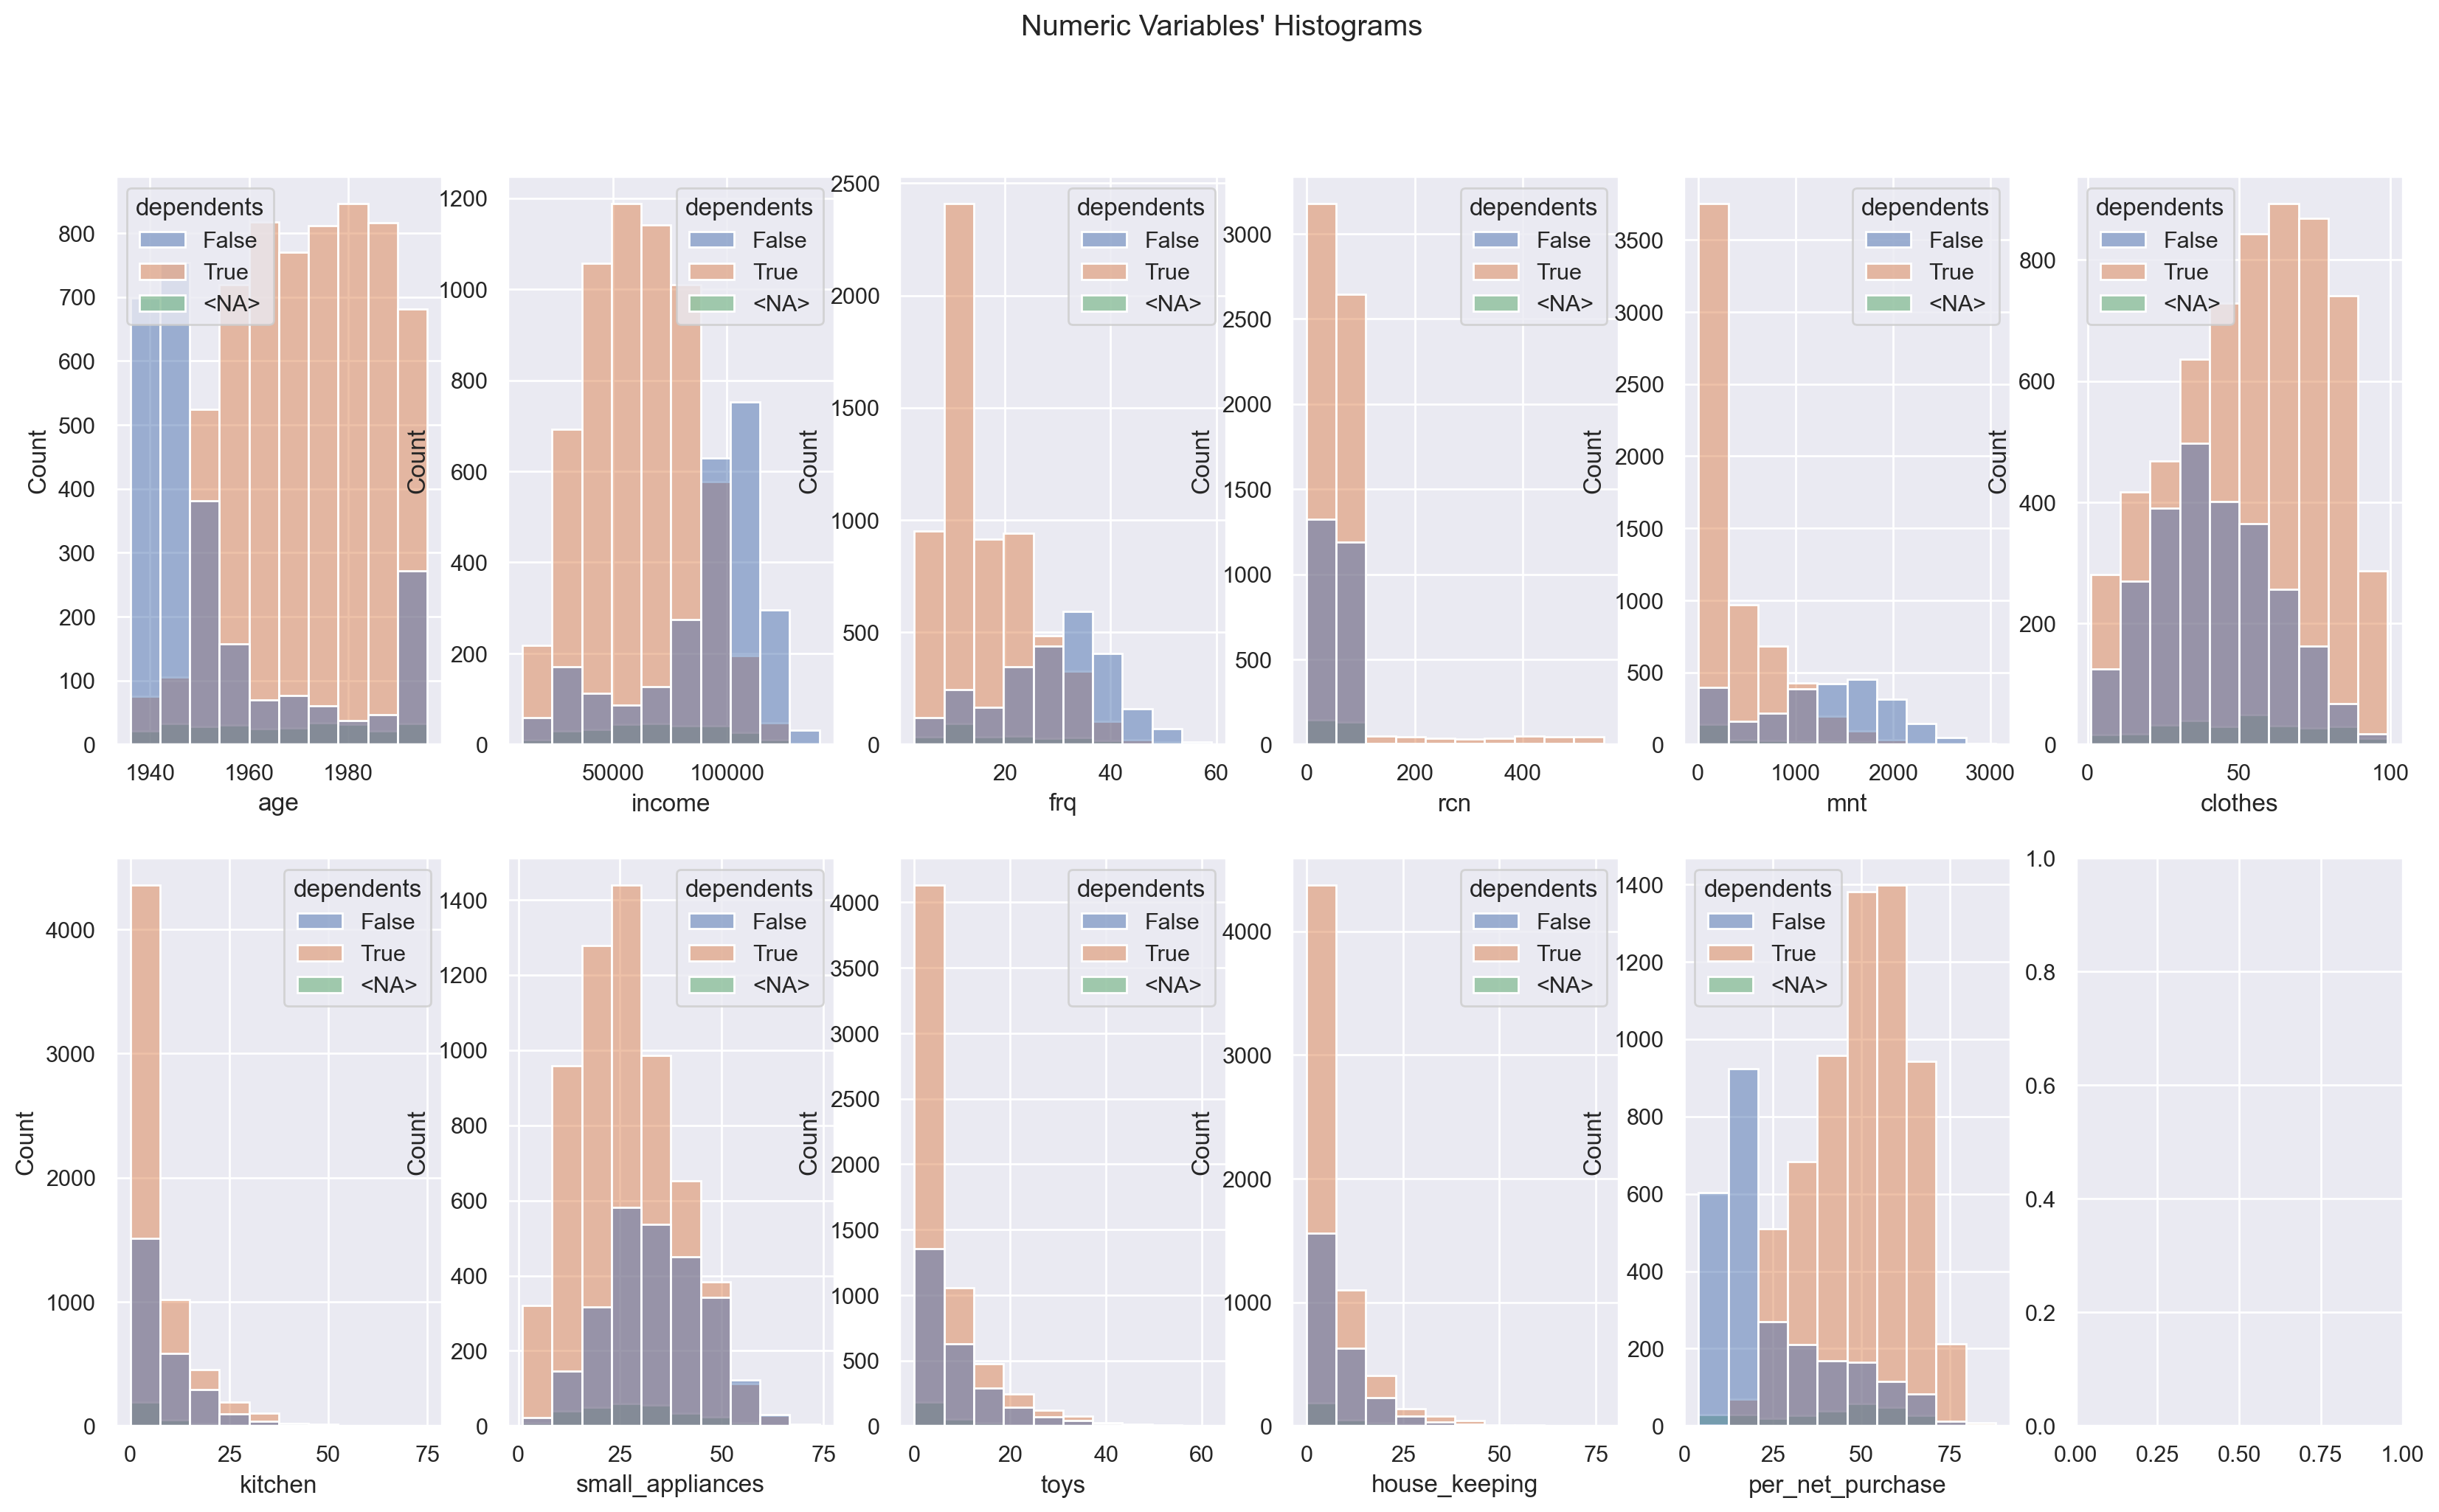

In [30]:
# Plot ALL Numeric Variables' Histograms in one figure

sns.set_style() ## Reset to darkgrid

sp_rows = 2
sp_cols = 6


# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 11))

# Plot data
for ax, feat in zip(axes.flatten(), metric_features): 
    sns.histplot(df_deps, x=feat, ax=ax, bins=10, hue='dependents')
    
# Layout
title = "Numeric Variables' Histograms"

plt.suptitle(title)

plt.show()

['False' 'True' '<NA>']
['False' 'True']


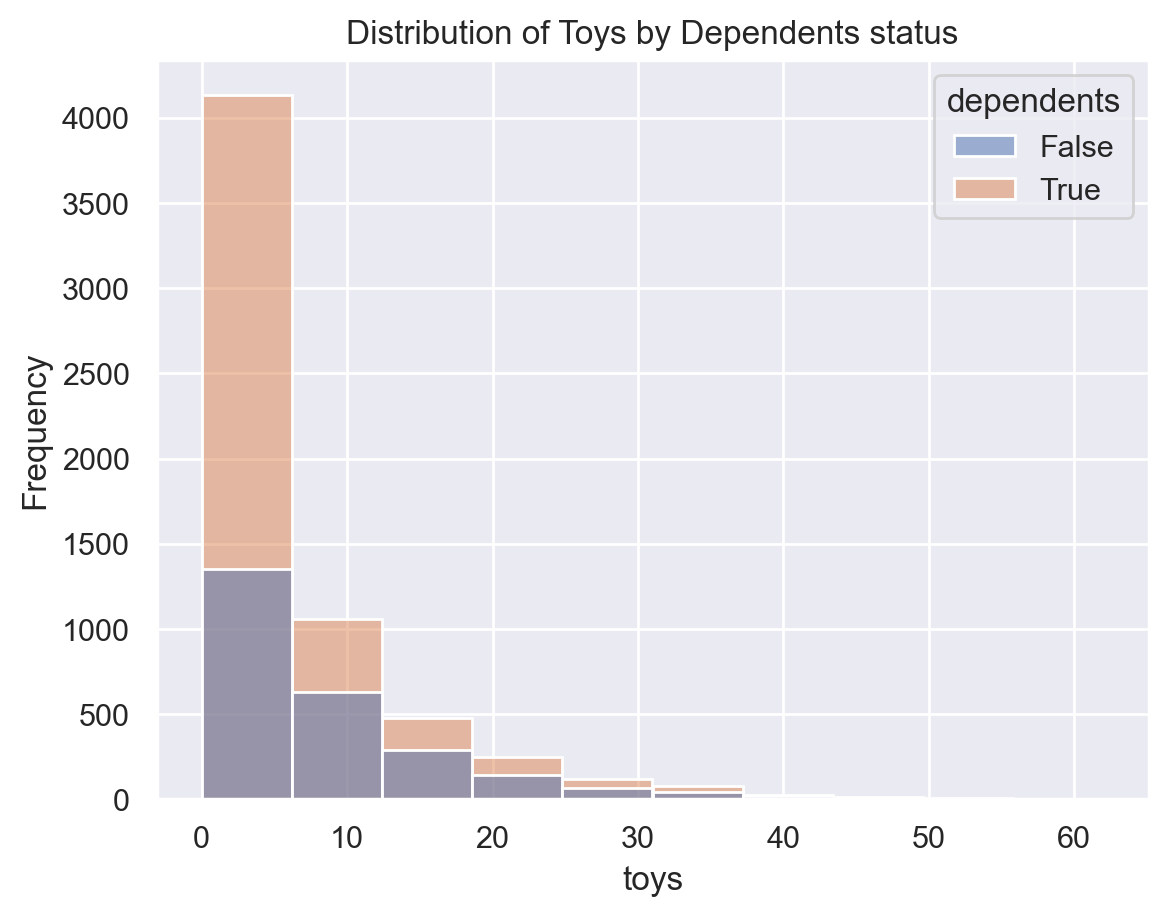

In [31]:
df_img = df_deps.copy()
print(df_img['dependents'].unique())
df_img = df_img[df_img['dependents'] != "<NA>"]
print(df_img['dependents'].unique())
sns.histplot(df_img, x='toys', bins=10, hue='dependents')
plt.ylabel('Frequency')
plt.title('Distribution of Toys by Dependents status')
plt.show()

### Scatterplots

Using seaborn, plot scatterplot of `age` vs `frq`

Use use the 'hue' parameter to color each point according to values of `gender`

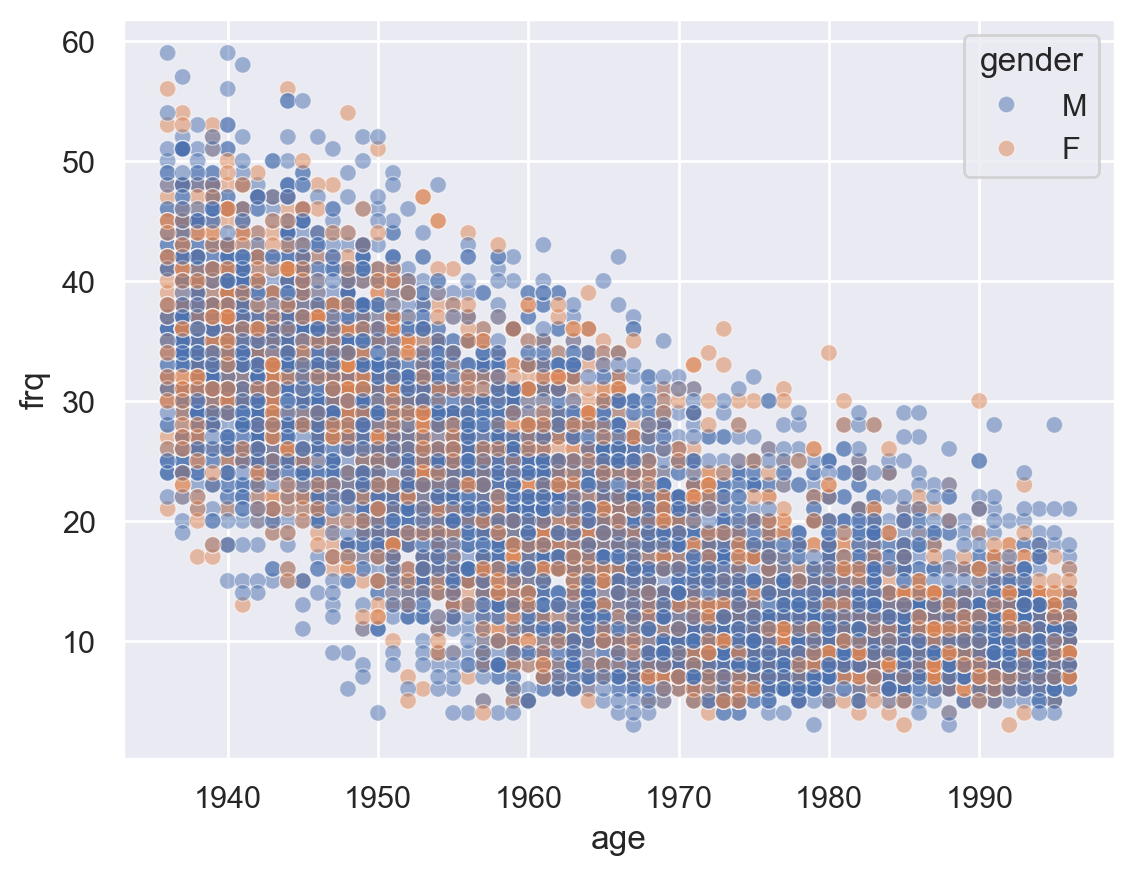

In [32]:
sns.scatterplot(df,
                x="age",
                y="frq", 
                alpha=.5,
                hue='gender',
               )


plt.show()

# Is this useful? 
# How can we improve this visualization?


### Density plots

Now try with seaborn kdeplot

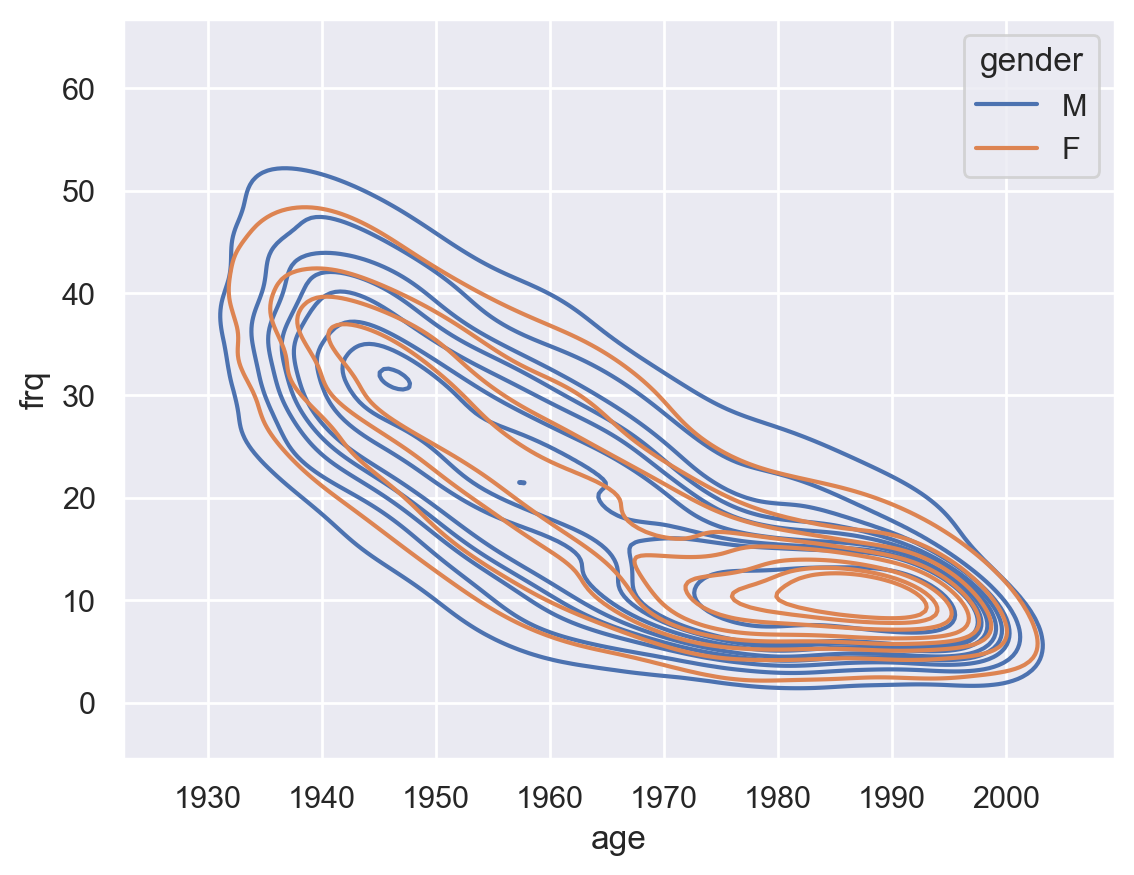

In [35]:
# Try seaborn kdeplot

sns.kdeplot(df,
            x="age",
            y="frq",            
            hue='gender')

plt.show()

Now try these with `hue='dependents'`

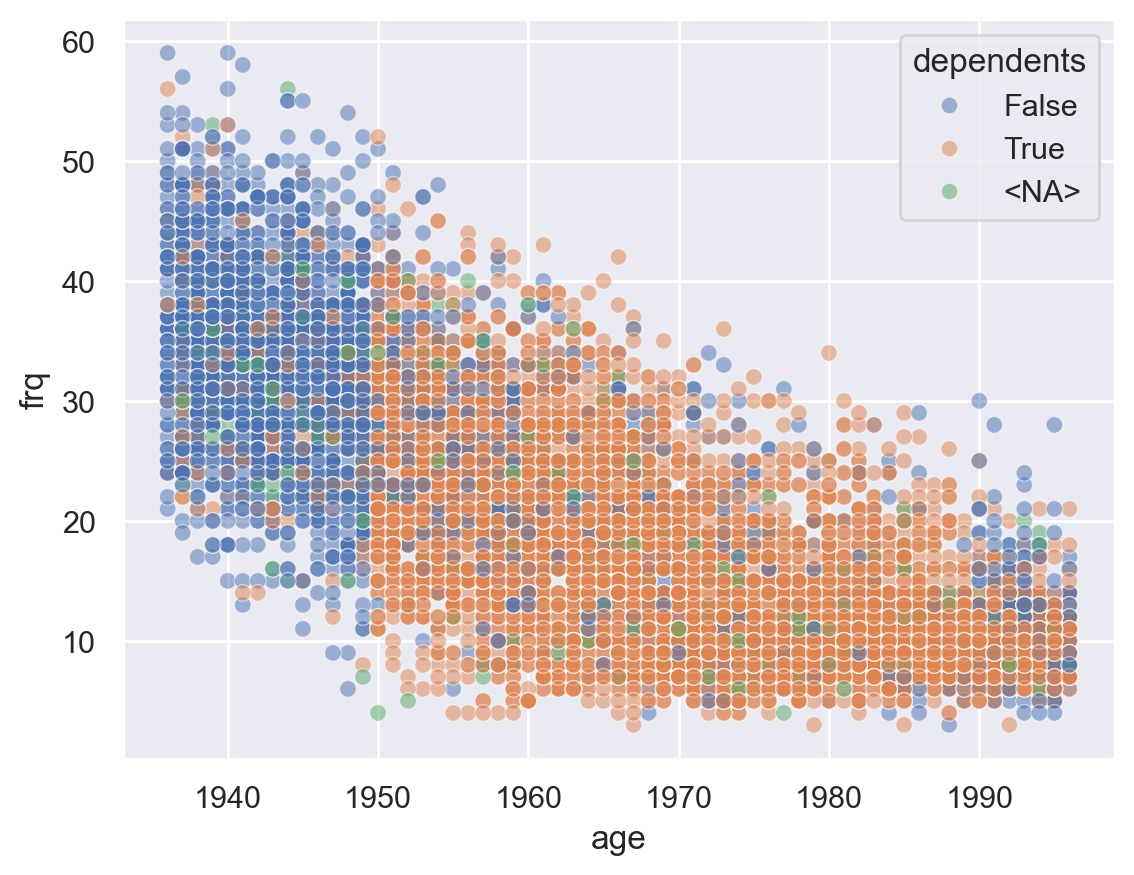

In [37]:
# sns.scatterplot with hue='dependents'

sns.scatterplot(df_deps,
                x="age",
                y="frq", 
                alpha=.5,
                hue='dependents',
               )


plt.show()

# Is this useful? 
# How can we improve this visualization?


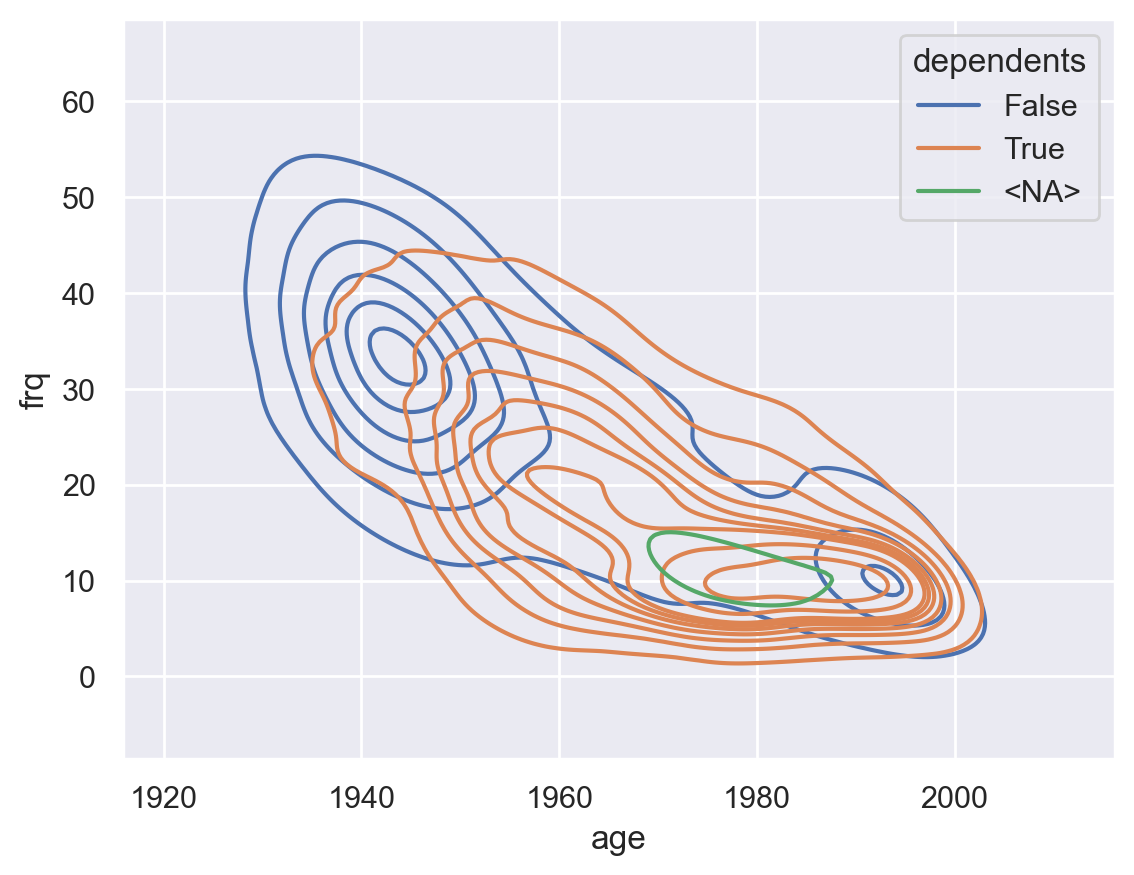

In [36]:
# sns.kdeplot with hue='dependents'

sns.kdeplot(df_deps,
            x="age",
            y="frq",            
            hue='dependents',)

plt.show()

### Pairplot

In [ ]:
# Pairwise Relationship of Numerical Variables
sns.set_style()

# Setting pairplot
sns.pairplot(df[metric_features + ['gender']], diag_kind="hist", hue='gender')

# Layout
plt.suptitle("Pairwise Relationship of Numerical Variables", fontsize=20)

plt.show()

### Three-way ANOVA

Another example of visualization. Although it is not a simple visualization to produce, it can be very informative.

https://seaborn.pydata.org/examples/pointplot_anova.html

Documentation of `pointplot()`: https://seaborn.pydata.org/generated/seaborn.pointplot.html#seaborn.pointplot

In [ ]:
non_metric_features

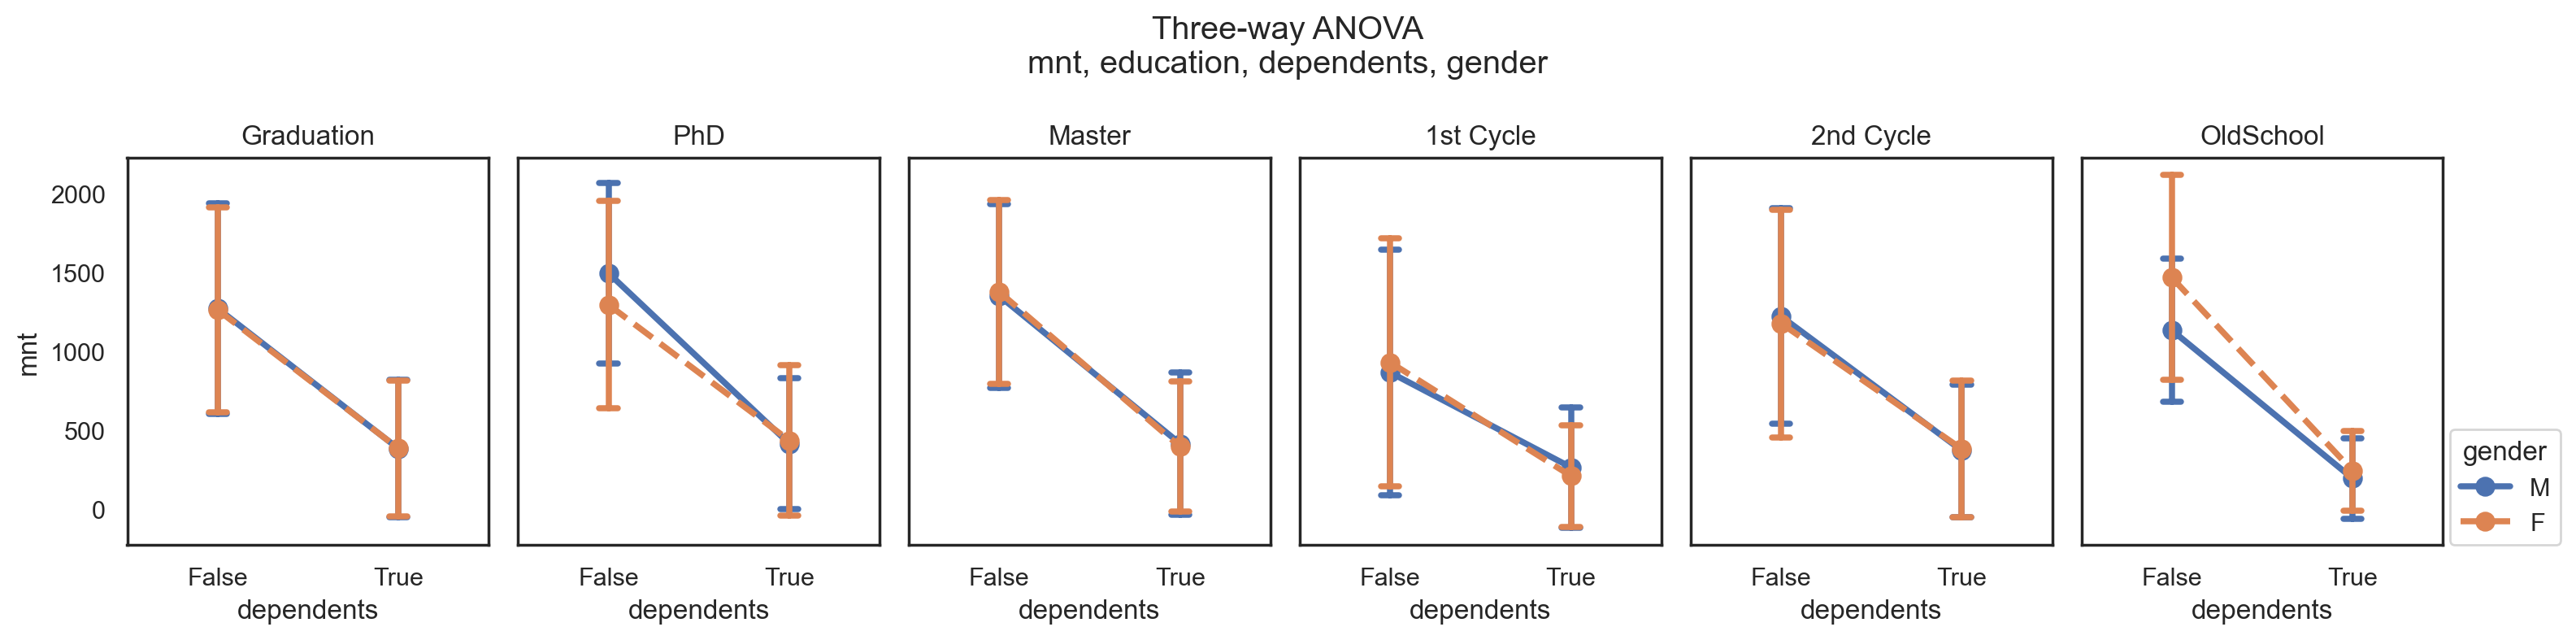

In [39]:
sns.set_style("white") # this resets our formatting defaults
# We filter only those with dependents not missing
xfeat = 'dependents'
huefeat='gender'
df_viz = df.loc[~df[xfeat].isna()]
educ_vals = df_viz.education.dropna().unique()

fig, axes = plt.subplots(1,len(educ_vals), figsize=(16,4), tight_layout=True, sharey=True)

for (axi, educ_i) in zip(axes, educ_vals):
    data_ = df_viz.loc[df_viz['education']==educ_i]
    sns.pointplot(data=data_, 
              y='mnt', 
              x=xfeat, 
              hue=huefeat, 
              errorbar='sd',
              linestyles=["-", "--"],
              capsize=.1,
              ax=axi
              )

    axi.legend([], frameon=False)
    axi.set_title(educ_i)


axes[-1].legend(loc=(1.02,0), title=huefeat)

fig.suptitle("Three-way ANOVA\nmnt, education, dependents, gender")
plt.show()

In [ ]:
# We filter only those with dependents not missing
xfeat = 'dependents'
df_viz = df.loc[~df[xfeat].isna()]


# notice we drop missing values in order to not plot it as a distinct value
educ_vals = df_viz.education.dropna().unique()


fig, axes = plt.subplots(
                len(metric_features), # number of rows of subplots
                len(educ_vals),       # number of cols of subplots
                figsize=(25,30),      # size of figure
                tight_layout=True,
                sharey="row")

for ax, (feat, educ_deg) in zip(axes.flatten(), product(metric_features, educ_vals)):
    # get the data for each subplot
    data = df_viz[df_viz.education == educ_deg].copy()
    data[xfeat] = data[xfeat].astype(str)
    
    # we are distinguishing points according to the variable "dependents"
    sns.pointplot(x=xfeat, y=feat, 
                  hue="gender", hue_order=["F", "M"],
                  errorbar='sd',
                  data=data, 
                  capsize=.1,
                  linestyles=["-", "--"],
                  ax=ax)

    # don't show all the legends
    ax.legend('', frameon=False)

    # set the x labels and legend of each axis
    ax.set_xlabel(xfeat)
    ax.set_title(educ_deg, fontsize=16, y=.8)
    


# set metric names
for ax, label in zip(axes[:,0], metric_features):
    ax.set_ylabel(label, fontsize=13)


# set figure title
plt.suptitle("Three-way ANOVA for each metric variable", fontsize=25, y=1)

# Set legend (gender)
handles, _ = axes[0,0].get_legend_handles_labels()
fig.legend(handles, ["F","M"], loc="upper right", title="Gender", title_fontsize=13, ncols=2, handlelength=6)
fig.subplots_adjust(hspace=.5)

plt.show()

### Comparing categoricals to numericals overview: 
- Univariate numerical distribution vs categorical (2 vars)
    - Histograms / Boxplots (for each category)

- Bivariate numericals distribution vs categorical (3 vars) 
    - Scatterplots / Hexbins / Density plots (colored for each category)

- Numerical vs 3 categoricals (4 vars)
    - 3-way ANOVA (pointplot)

# A tool to assist you through your exploratory data analysis

Optionally, you may use `pandas-profiling` as a first approach to your data analysis. Remember, although this tool provides excelent insights about the data you're working with, it is not enough to perform a proper analysis.

## Install a package from a different conda channel

### If you had issues installing ydata-profiling previously

Open a terminal (Anaconda Terminal) and run the following commands.

*If you are using a custom conda environment, run this first:*

    conda activate <ENV_NAME>
    
Then:

    conda install -c conda-forge ydata-profiling==4.5.0 -y
    
OR from a jupyter cell:

    !conda install -c conda-forge ydata-profiling==4.5.0 -y

OR if conda doesn't work:

    !pip install -U ydata-profiling


- The `<ENV_NAME>` refers to the name of the environment you'll be working with for this project
- The `!` indicates a terminal command
- The `-c` flag indicates the channel we're using to get the package
- The `-y` flag indicates that we're confirming the installation of pandas-profiling and its dependencies a priori

We're installing `ydata-profiling` through this method because Anaconda's `default` channel contains an outdated version of this package, whereas the channel `conda-forge` has an updated version.

In [ ]:
profile = ProfileReport(
    df, 
    title='Tugas Customer Data',
    correlations={
        "pearson": {"calculate": True},
        "spearman": {"calculate": False},
        "kendall": {"calculate": False},
        "phi_k": {"calculate": False},
        "cramers": {"calculate": False},
    },
)

In [ ]:
profile.to_notebook_iframe()

In [ ]:
profile.to_file(os.path.join('..', 'figures', "eda", "tugas_customer_data.html"))

# Optional Exercise

Download the [Amazing Creative Desk Coworking dataset](https://elearning.novaims.unl.pt/mod/folder/view.php?id=113931). Using the `acdc_dataset.csv` file, perform the same exercises that we did in this notebook.

Identify the metric and non-metric features in this dataset.

**Visualize the different variables present in this dataset. Are there any interesting relationships present?**

# Tools and resources for better visualizations

https://www.simplifiedsciencepublishing.com/resources/best-color-palettes-for-scientific-figures-and-data-visualizations

https://python-graph-gallery.com/

https://plotly.com/python/plotly-express/ (Interactive Visualizations,  more simplified)

https://plotly.com/python/graph-objects/ (Interactive Visualizations, more customization)


# During our Exploratory Data Analysis (EDA), we must also account for:
- Incoherencies
- Outliers
- Missing values
- Feature Engineering

# Questions?


# NEXT Notebook: Data Preprocessing

## Depending on the context, various steps must be considered when performing Data Preprocessing. 

The most relevant steps are the following:
- Coherence check (find inconsistent values, missing values, outliers and any other problem you may find in your dataset)
- Data editing (fix inconsistent values)
- Data cleansing (drop observations - Outlier removal and removal of inconsistent values and/or features)
- Data wrangling (feature extraction/engineering and transformation)
- Data reduction (reducing the dimensionality of a dataset, producing summary statistics, reducing the number of records in a dataset)